<a href="https://colab.research.google.com/github/sushant758/ML-Exercises/blob/main/Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1144]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [1145]:
df = pd.read_csv('train.csv')

In [1146]:
df.shape

(1200000, 21)

In [1147]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [1148]:
df.columns

Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

In [1149]:
df.duplicated().sum()

np.int64(0)

In [1150]:
# Target variable is Premium Amount

In [1151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [1152]:
df = df.drop(columns=['id'])

In [1153]:
# Age
df['Age'].isnull().sum()

np.int64(18705)

In [1154]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [1155]:
df['Age'].isnull().sum()

np.int64(0)

<Axes: xlabel='Age'>

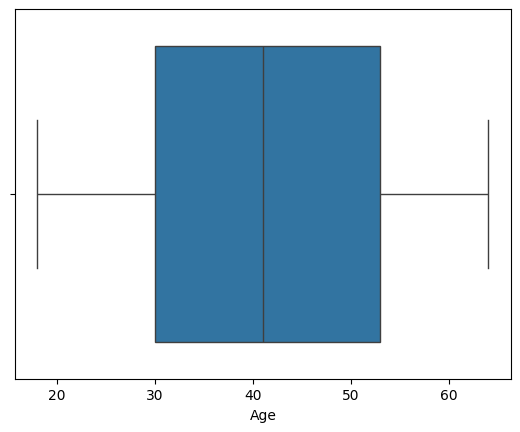

In [1156]:
sns.boxplot(x=df['Age'])

In [1157]:
# Gender
df['Gender'].isnull().sum()

np.int64(0)

In [1158]:
df['Gender'].value_counts()

,count
Gender,
Male,602571
Female,597429


In [1159]:
df['is_female'] = df['Gender'].map({'Male' : 0 , 'Female' : 1})

In [1160]:
df['is_female'].value_counts()

,count
is_female,
0,602571
1,597429


In [1161]:
df.drop(columns=['Gender'], inplace=True)

In [1162]:
# Annual Income
df['Annual Income'].isnull().sum()

np.int64(44949)

In [1163]:
df['Annual Income'] = df['Annual Income'].fillna(df['Annual Income'].median())

In [1164]:
df['Annual Income'].isnull().sum()

np.int64(0)

<Axes: xlabel='Annual Income'>

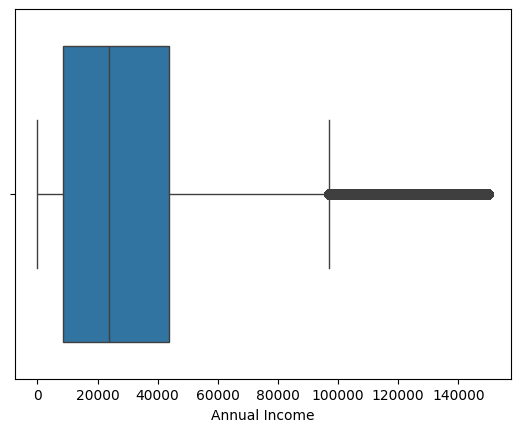

In [1165]:
sns.boxplot(x=df['Annual Income'])

In [1166]:
df['Annual Income'].skew()

np.float64(1.5229537478396937)

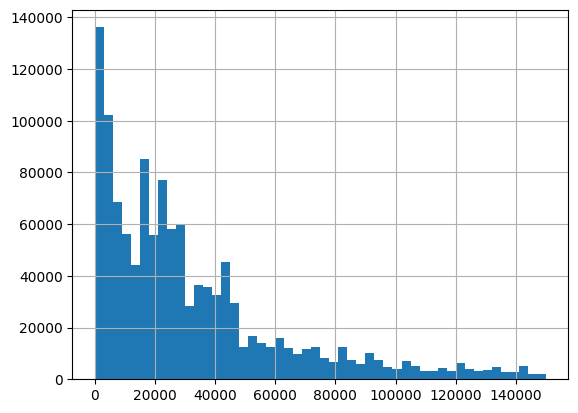

In [1167]:
df['Annual Income'].hist(bins=50)
plt.show()

In [1168]:
df['Annual Income'] = np.sqrt(df['Annual Income'])

In [1169]:
df['Annual Income'].skew()

np.float64(0.4971849183192823)

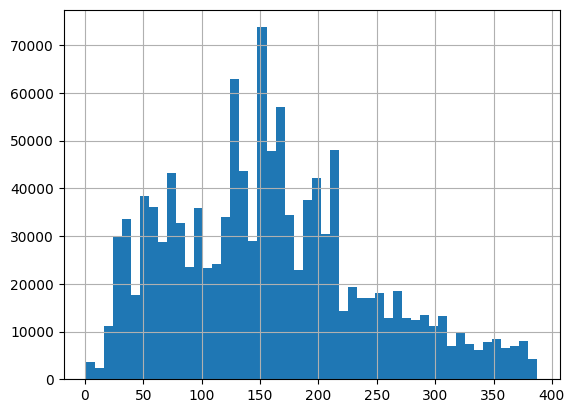

In [1170]:
df['Annual Income'].hist(bins=50)
plt.show()

<Axes: xlabel='Annual Income'>

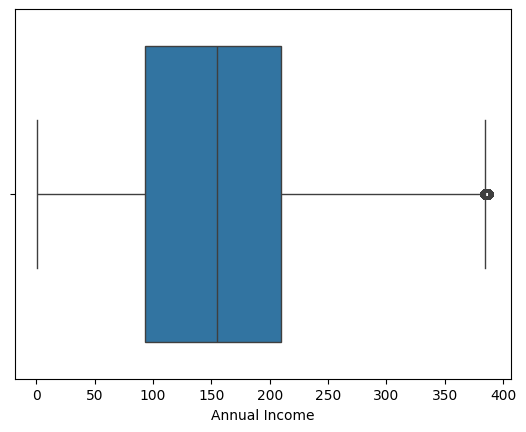

In [1171]:
sns.boxplot(x=df['Annual Income'])

<Axes: >

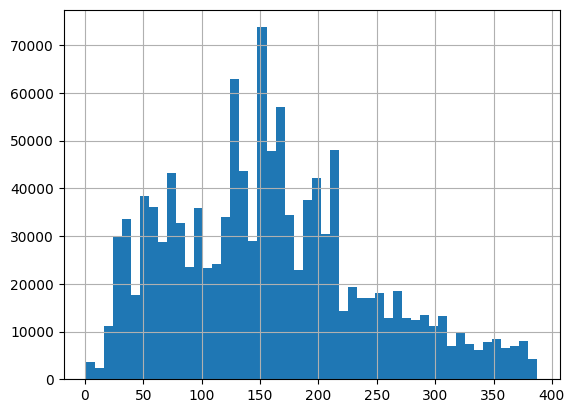

In [1172]:
df['Annual Income'].hist(bins=50)

In [1173]:
# Marital Status
df['Marital Status'].value_counts(dropna=False)

,count
Marital Status,
Single,395391
Married,394316
Divorced,391764
NaN,18529


In [1174]:
# When i will fill with mode at here , all 18,529 missing values will get assigned to the single.

In [1175]:
df['Marital Status'] = df['Marital Status'].fillna('Unknown')

In [1176]:
df['is_married'] = (df['Marital Status'] == 'Married').astype(int)
df['is_divorced'] = (df['Marital Status'] == 'Divorced').astype(int)

In [1177]:
df.drop(columns=['Marital Status'], inplace=True)

In [1178]:
df.head()

,Age,Annual Income,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,...,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,is_female,is_married,is_divorced
0,19.0,100.244701,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,...,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1,1,0
1,39.0,177.983145,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,...,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1,0,1
2,23.0,160.006250,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,...,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0,0,1
3,21.0,376.636429,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,...,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0,1,0
4,21.0,199.125589,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,...,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0,0,0


In [1179]:
df.head()

,Age,Annual Income,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,...,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,is_female,is_married,is_divorced
0,19.0,100.244701,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,...,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1,1,0
1,39.0,177.983145,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,...,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1,0,1
2,23.0,160.006250,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,...,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0,0,1
3,21.0,376.636429,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,...,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0,1,0
4,21.0,199.125589,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,...,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0,0,0


In [1180]:
# Number of Dependents
df['Number of Dependents'].value_counts(dropna=False)

,count
Number of Dependents,
3.0,221475
4.0,220340
0.0,218124
2.0,215313
1.0,215076
NaN,109672


In [1181]:
df['Number of Dependents'] = df['Number of Dependents'].fillna(df['Number of Dependents'].median())

In [1182]:
df['Number of Dependents'].value_counts(dropna=False)

,count
Number of Dependents,
2.0,324985
3.0,221475
4.0,220340
0.0,218124
1.0,215076


In [1183]:
df['Number of Dependents'] = df['Number of Dependents'].astype(int)

In [1184]:
df['Number of Dependents'].skew()

np.float64(-0.011889218273089008)

In [1185]:
# Education Level
df['Education Level'].value_counts(dropna=False)

,count
Education Level,
Master's,303818
PhD,303507
Bachelor's,303234
High School,289441


In [1186]:
df = pd.get_dummies(df, columns=['Education Level'] , dtype=int)

In [1187]:
df.head()

,Age,Annual Income,Number of Dependents,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,...,Exercise Frequency,Property Type,Premium Amount,is_female,is_married,is_divorced,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD
0,19.0,100.244701,1,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,...,Weekly,House,2869.0,1,1,0,1,0,0,0
1,39.0,177.983145,3,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,...,Monthly,House,1483.0,1,0,1,0,0,1,0
2,23.0,160.006250,3,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,...,Weekly,House,567.0,0,0,1,0,1,0,0
3,21.0,376.636429,2,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,...,Daily,Apartment,765.0,0,1,0,1,0,0,0
4,21.0,199.125589,1,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,...,Weekly,House,2022.0,0,0,0,1,0,0,0


In [1188]:
# Occupation
df['Occupation'].value_counts(dropna=False)

,count
Occupation,
NaN,358075
Employed,282750
Self-Employed,282645
Unemployed,276530


In [1189]:
df['Occupation'].fillna('Unknown' , inplace=True)

In [1190]:
df['Occupation'].value_counts(dropna=False)

,count
Occupation,
Unknown,358075
Employed,282750
Self-Employed,282645
Unemployed,276530


In [1191]:
df = pd.get_dummies(df, columns=['Occupation'] , dtype=int)

In [1192]:
# Health Score
df['Health Score'].value_counts(dropna=False)

,count
Health Score,
NaN,74076
19.927241,128
25.907650,124
19.869701,119
22.955402,104
...,...
7.442964,1
4.551825,1
31.391907,1


In [1193]:
df['Health Score'] = df['Health Score'].fillna(df['Health Score'].mean())

In [1194]:
print(df['Health Score'].min())
print(df['Health Score'].max())

2.0122371818911766
58.97591405405534


In [1195]:
df['Health Score'].skew()

np.float64(0.2913221653165929)

In [1196]:
# Location
df['Location'].value_counts(dropna=False)

,count
Location,
Suburban,401542
Rural,400947
Urban,397511


In [1197]:
df = pd.get_dummies(df, columns=['Location'] , drop_first= True , dtype=int)

In [1198]:
# Policy Type
df['Policy Type'].value_counts(dropna=False)

,count
Policy Type,
Premium,401846
Comprehensive,399600
Basic,398554


In [1199]:
df = pd.get_dummies(df, columns=['Policy Type'] , drop_first=True ,  dtype=int)

In [1200]:
# Previous Claims
df['Previous Claims'].value_counts(dropna=False)

,count
Previous Claims,
NaN,364029
0.0,305433
1.0,300811
2.0,167661
3.0,49011
4.0,10668
5.0,2018
6.0,302
7.0,58


In [1201]:
df['Previous Claims'] = df['Previous Claims'].fillna(df['Previous Claims'].median())

In [1202]:
df['Previous Claims'] = np.log1p(df['Previous Claims'])

In [1203]:
df['Previous Claims'].skew()

np.float64(-0.15437968360022583)

<Axes: xlabel='Previous Claims'>

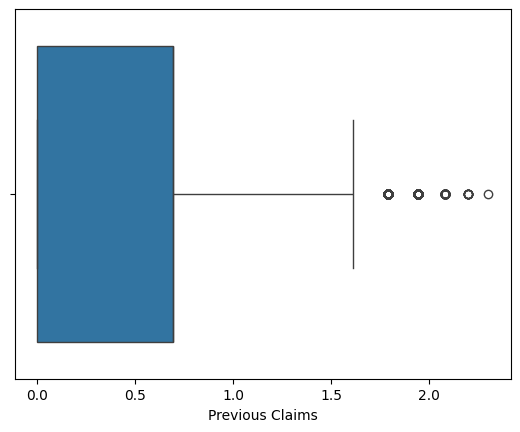

In [1204]:
sns.boxplot(x=df['Previous Claims'])

In [1205]:
Q1 = df['Previous Claims'].quantile(0.25)
Q3 = df['Previous Claims'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['Previous Claims'] = df['Previous Claims'].clip(lower, upper)

In [1206]:
df['Previous Claims'].skew()

np.float64(-0.1644502424285764)

<Axes: xlabel='Previous Claims'>

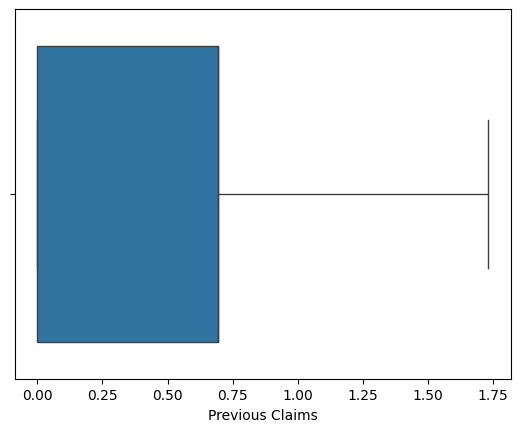

In [1207]:
sns.boxplot(x=df['Previous Claims'])

In [1208]:
# Vehicle Age
df['Vehicle Age'].value_counts(dropna=False)

,count
Vehicle Age,
17.0,62577
0.0,61615
11.0,61483
18.0,61399
10.0,61351
15.0,60817
14.0,60815
12.0,60718
19.0,60495


In [1209]:
df['Vehicle Age'] = df['Vehicle Age'].fillna(df['Vehicle Age'].median())

In [1210]:
df['Vehicle Age'].skew()

np.float64(-0.020410047347880367)

In [1211]:
# Credit Score
df['Credit Score'].value_counts(dropna=False)

,count
Credit Score,
NaN,137882
434.0,4288
431.0,4277
757.0,4021
713.0,3977
...,...
660.0,472
560.0,444
610.0,404


In [1212]:
df['Credit Score'] = df['Credit Score'].fillna(df['Credit Score'].median())

In [1213]:
df['Credit Score'].value_counts(dropna=False)

,count
Credit Score,
595.0,141069
434.0,4288
431.0,4277
757.0,4021
713.0,3977
...,...
660.0,472
560.0,444
610.0,404


In [1214]:
df['Credit Score'].skew()

np.float64(-0.12578590724748864)

<Axes: xlabel='Credit Score'>

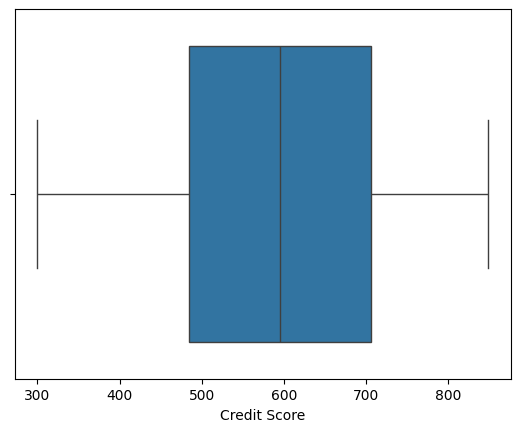

In [1215]:
sns.boxplot(x=df['Credit Score'])

In [1216]:
# Insurance Duration
df['Insurance Duration'].value_counts(dropna=False)

,count
Insurance Duration,
9.0,137781
1.0,135072
8.0,133800
7.0,133592
5.0,132253
4.0,132182
6.0,132141
3.0,132018
2.0,131160


In [1217]:
df['Insurance Duration'] = df['Insurance Duration'].fillna(df['Insurance Duration'].median())

In [1218]:
df['Insurance Duration'].skew()

np.float64(-0.008793288411603858)

<Axes: xlabel='Insurance Duration'>

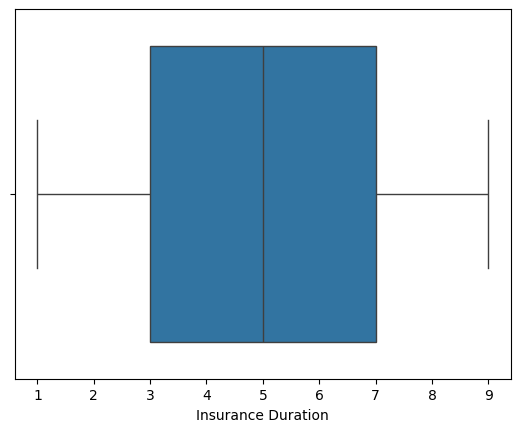

In [1219]:
sns.boxplot(x=df['Insurance Duration'])

In [1220]:
# Policy Start Date
df['Policy Start Date'].value_counts(dropna=False)

,count
Policy Start Date,
2020-02-08 15:21:39.134960,142
2022-02-02 15:21:39.134960,137
2023-08-13 15:21:39.155231,137
2022-08-30 15:21:39.134960,134
2024-02-19 15:21:39.134960,118
...,...
2022-09-24 15:21:39.199447,1
2020-09-17 15:21:39.258696,1
2021-08-20 15:21:39.286113,1


In [1221]:
# from this column extracting year, month , day , ploicy age days

In [1222]:
df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'])

df['policy_year'] = df['Policy Start Date'].dt.year
df['policy_month'] = df['Policy Start Date'].dt.month
df['policy_day_of_week'] = df['Policy Start Date'].dt.dayofweek
df['policy_age_days'] = (pd.Timestamp.now() - df['Policy Start Date']).dt.days

In [1223]:
df.drop(columns=['Policy Start Date'], inplace=True)

In [1224]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,...,Occupation_Unemployed,Occupation_Unknown,Location_Suburban,Location_Urban,Policy Type_Comprehensive,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,Poor,No,...,0,0,0,1,0,1,2023,12,5,912
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,Average,Yes,...,0,1,0,0,1,0,2023,6,0,1106
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,Good,Yes,...,0,0,1,0,0,1,2023,9,5,996
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,Poor,Yes,...,0,1,0,0,0,0,2024,6,2,740
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,Poor,Yes,...,0,0,0,0,0,1,2021,12,2,1664


In [1225]:
# Customer Feedback
df['Customer Feedback'].value_counts(dropna=False)

,count
Customer Feedback,
Average,377905
Poor,375518
Good,368753
NaN,77824


In [1226]:
df['Customer Feedback'] = df['Customer Feedback'].fillna('Unknown')

In [1227]:
df = pd.get_dummies(df, columns=['Customer Feedback'] ,drop_first=True ,dtype=int)

In [1228]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,...,Location_Urban,Policy Type_Comprehensive,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days,Customer Feedback_Good,Customer Feedback_Poor,Customer Feedback_Unknown
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,No,Weekly,...,1,0,1,2023,12,5,912,0,1,0
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,Yes,Monthly,...,0,1,0,2023,6,0,1106,0,0,0
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,Yes,Weekly,...,0,0,1,2023,9,5,996,1,0,0
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,Yes,Daily,...,0,0,0,2024,6,2,740,0,1,0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,Yes,Weekly,...,0,0,1,2021,12,2,1664,0,1,0


In [1229]:
# Smoking Status
df['Smoking Status'].value_counts(dropna=False)

,count
Smoking Status,
Yes,601873
No,598127


In [1230]:
df['Smoking Status'] = df['Smoking Status'].map({'Yes': 1, 'No': 0})

In [1231]:
# Exercise Frequency
df['Exercise Frequency'].value_counts(dropna=False)

,count
Exercise Frequency,
Weekly,306179
Monthly,299830
Rarely,299420
Daily,294571


In [1232]:
# df['Exercise Frequency'] = df['Exercise Frequency'].fillna(df['Exercise Frequency'].median())

In [1233]:
order = {'Rarely' : 0 , 'Monthly': 1 , 'Weekly':3 , 'Daily': 4}
df['Exercise Frequency'] = df['Exercise Frequency'].map(order)

In [1234]:
df['Exercise Frequency'].value_counts(dropna=False)

,count
Exercise Frequency,
3,306179
1,299830
0,299420
4,294571


In [1235]:
# Property Type
df['Property Type'].value_counts(dropna=False)

,count
Property Type,
House,400349
Apartment,399978
Condo,399673


In [1236]:
df = pd.get_dummies(df, columns=['Property Type'] ,drop_first=True ,  dtype=int)

In [1237]:
df['Premium Amount'].value_counts(dropna=False)

,count
Premium Amount,
25.0,4268
24.0,3901
20.0,3849
23.0,3524
28.0,3418
...,...
4107.0,1
4996.0,1
4937.0,1


In [1238]:
df['Premium Amount'].isnull().sum()

np.int64(0)

In [1239]:
has_negative = (df['Premium Amount'] < 0).any()
print(has_negative)

False


In [1240]:
y = df["Premium Amount"]

print("Min value:", y.min())
print("Number of zeros:", (y == 0).sum())
print("Number of negatives:", (y < 0).sum())
print("NaNs:", y.isna().sum())
print("Infinite:", np.isinf(y).sum())

Min value: 20.0
Number of zeros: 0
Number of negatives: 0
NaNs: 0
Infinite: 0


In [1241]:
# Premium Amount
df['Premium Amount'].value_counts(dropna=False)

,count
Premium Amount,
25.0,4268
24.0,3901
20.0,3849
23.0,3524
28.0,3418
...,...
4107.0,1
4996.0,1
4937.0,1


In [1242]:
df['Premium Amount'].skew()

np.float64(1.2409154932891036)

In [1243]:
# First reset to original values - do you still have the original column?
df['Premium Amount'] = np.sqrt(df['Premium Amount'])
print(df['Premium Amount'].skew())

0.19927083763811093


In [1244]:
df['Premium Amount'].skew()

np.float64(0.19927083763811093)

<Axes: xlabel='Premium Amount'>

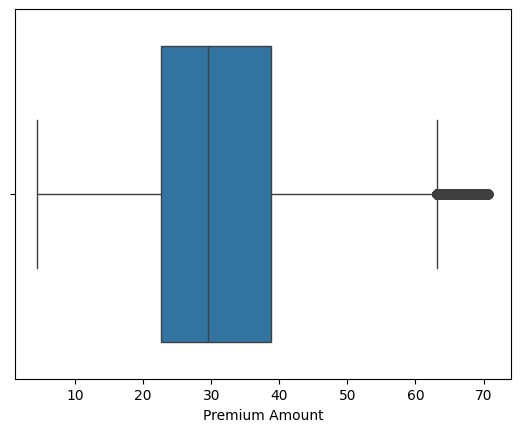

In [1245]:
sns.boxplot(x=df['Premium Amount'])

In [1246]:
df['Premium Amount'].skew()

np.float64(0.19927083763811093)

<Axes: xlabel='Premium Amount'>

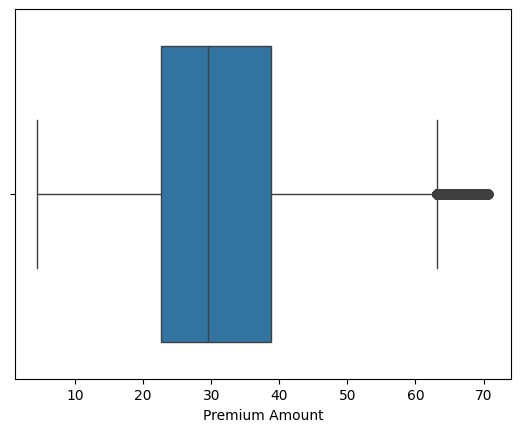

In [1247]:
sns.boxplot(x=df['Premium Amount'])

In [1248]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,...,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days,Customer Feedback_Good,Customer Feedback_Poor,Customer Feedback_Unknown,Property Type_Condo,Property Type_House
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,0,3,...,1,2023,12,5,912,0,1,0,0,1
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,1,1,...,0,2023,6,0,1106,0,0,0,0,1
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,1,3,...,1,2023,9,5,996,1,0,0,0,1
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,1,4,...,0,2024,6,2,740,0,1,0,0,0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,1,3,...,1,2021,12,2,1664,0,1,0,0,1


In [1249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 35 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Age                          1200000 non-null  float64
 1   Annual Income                1200000 non-null  float64
 2   Number of Dependents         1200000 non-null  int64  
 3   Health Score                 1200000 non-null  float64
 4   Previous Claims              1200000 non-null  float64
 5   Vehicle Age                  1200000 non-null  float64
 6   Credit Score                 1200000 non-null  float64
 7   Insurance Duration           1200000 non-null  float64
 8   Smoking Status               1200000 non-null  int64  
 9   Exercise Frequency           1200000 non-null  int64  
 10  Premium Amount               1200000 non-null  float64
 11  is_female                    1200000 non-null  int64  
 12  is_married                   1200000 non-n

In [1250]:
df.isnull().sum()

,0
Age,0
Annual Income,0
Number of Dependents,0
Health Score,0
Previous Claims,0
Vehicle Age,0
Credit Score,0
Insurance Duration,0
Smoking Status,0
Exercise Frequency,0


In [1251]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [1252]:
df.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,...,Policy Type_Premium,policy_year,policy_month,policy_day_of_week,policy_age_days,Customer Feedback_Good,Customer Feedback_Poor,Customer Feedback_Unknown,Property Type_Condo,Property Type_House
0,19.0,100.244701,1,22.598761,1.098612,17.0,372.0,5.0,0,3,...,1,2023,12,5,912,0,1,0,0,1
1,39.0,177.983145,3,15.569731,0.693147,12.0,694.0,2.0,1,1,...,0,2023,6,0,1106,0,0,0,0,1
2,23.0,160.006250,3,47.177549,0.693147,14.0,595.0,3.0,1,3,...,1,2023,9,5,996,1,0,0,0,1
3,21.0,376.636429,2,10.938144,0.693147,0.0,367.0,1.0,1,4,...,0,2024,6,2,740,0,1,0,0,0
4,21.0,199.125589,1,20.376094,0.000000,8.0,598.0,4.0,1,3,...,1,2021,12,2,1664,0,1,0,0,1


In [1291]:
corr_with_target = (
    df.corr(numeric_only=True)["Premium Amount"]
      .drop("Premium Amount")
      .sort_values(key=abs, ascending=False)
)

print(corr_with_target)

Annual Income                 -0.051021
Credit Score                  -0.038123
Previous Claims                0.032538
Customer Feedback_Unknown      0.028113
Health Score                   0.016792
policy_year                   -0.010914
policy_age_days                0.010072
Occupation_Unknown            -0.006790
policy_month                   0.006049
Customer Feedback_Good        -0.004888
Occupation_Employed            0.004157
Customer Feedback_Poor        -0.003291
Age                           -0.002438
is_divorced                   -0.002143
is_married                    -0.001944
Occupation_Self-Employed       0.001754
Occupation_Unemployed          0.001421
Number of Dependents          -0.001401
Location_Urban                 0.001349
Education Level_High School    0.001271
Property Type_Condo           -0.001132
Policy Type_Premium           -0.000797
Education Level_PhD           -0.000701
Education Level_Master's      -0.000668
Vehicle Age                    0.000504


In [1292]:
weak_features = corr_with_target[abs(corr_with_target) < 0.01]

print(weak_features)

Occupation_Unknown            -0.006790
policy_month                   0.006049
Customer Feedback_Good        -0.004888
Occupation_Employed            0.004157
Customer Feedback_Poor        -0.003291
Age                           -0.002438
is_divorced                   -0.002143
is_married                    -0.001944
Occupation_Self-Employed       0.001754
Occupation_Unemployed          0.001421
Number of Dependents          -0.001401
Location_Urban                 0.001349
Education Level_High School    0.001271
Property Type_Condo           -0.001132
Policy Type_Premium           -0.000797
Education Level_PhD           -0.000701
Education Level_Master's      -0.000668
Vehicle Age                    0.000504
Smoking Status                 0.000471
Location_Suburban             -0.000253
is_female                      0.000196
Exercise Frequency             0.000163
Education Level_Bachelor's     0.000118
Insurance Duration             0.000114
Property Type_House            0.000076


#  Creating Model

In [1293]:
corr_with_target = (
    df.corr(numeric_only=True)["Premium Amount"]
      .drop("Premium Amount")
)

selected_features = corr_with_target[
    abs(corr_with_target) >= 0.01
].index.tolist()

print("Selected Features:")
print(selected_features)

X = df[selected_features]
y = df["Premium Amount"]

Selected Features:
['Annual Income', 'Health Score', 'Previous Claims', 'Credit Score', 'policy_year', 'policy_age_days', 'Customer Feedback_Unknown']


In [1294]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(960000, 7) (240000, 7)


In [1295]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1296]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [1297]:
y_pred = model.predict(X_test_scaled)

In [1298]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

RMSE : 13.064443431327858
MAE  : 10.326859136093395
R²   : 0.0074212892356368965


In [1253]:
# X = df.drop(columns=["Premium Amount"])
# y = df["Premium Amount"]

In [1254]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )


In [1255]:
# from sklearn.linear_model import LinearRegression

# model = LinearRegression()

# model.fit(X_train, y_train)

In [1256]:
# y_pred_sqrt = model.predict(X_test)

In [1257]:
# y_pred = y_pred_sqrt ** 2
# y_actual = y_test ** 2


In [1258]:
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import mean_absolute_error
# from sklearn.metrics import r2_score

# rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
# mae = mean_absolute_error(y_actual, y_pred)
# r2 = r2_score(y_actual, y_pred)

# print("RMSE :", rmse)
# print("MAE  :", mae)
# print("R²   :", r2)

In [1259]:
# from sklearn.dummy import DummyRegressor
# from sklearn.metrics import r2_score

# dummy = DummyRegressor(strategy="mean")

# dummy.fit(X_train, y_train)

# dummy_pred = dummy.predict(X_test)

# # Back-transform
# dummy_pred = dummy_pred**2
# y_actual = y_test**2

# print("Dummy R²:", r2_score(y_actual, dummy_pred))

In [1260]:
# train_pred = model.predict(X_train)

# from sklearn.metrics import r2_score

# print("Train R²:", r2_score(y_train, train_pred))

In [1261]:
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )

# rf.fit(X_train, y_train)

# pred = rf.predict(X_test)

# from sklearn.metrics import r2_score

# print("R²:", r2_score(y_test, pred))

In [1262]:
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import KFold
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [1263]:
# from scipy.special import inv_boxcox


In [1264]:

# X = df.drop(columns=["Premium Amount", "Premium_Amount_BoxCox"])

# # Box-Cox transformed target
# y = df["Premium_Amount_BoxCox"]

In [1265]:
# ============================================
# STEP 3: Create 5-Fold CV
# ============================================

# kf = KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )


In [1266]:
# ============================================
# STEP 4: Create Linear Regression Model
# ============================================

# model = LinearRegression()

In [1267]:
# # ============================================
# # STEP 5: Run 5-Fold Cross Validation
# # ============================================

# rmse_scores = []
# mae_scores = []
# r2_scores = []

# for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

#     print(f"\n{'='*50}")
#     print(f"Fold {fold}")
#     print(f"{'='*50}")

#     # Split data
#     X_train = X.iloc[train_idx]
#     X_valid = X.iloc[valid_idx]

#     y_train = y.iloc[train_idx]
#     y_valid = y.iloc[valid_idx]

#     # Train model
#     model.fit(X_train, y_train)

#     # Predict on Box-Cox scale
#     y_pred_boxcox = model.predict(X_valid)

#     # Convert predictions back to original scale
#     y_pred = inv_boxcox(y_pred_boxcox, lambda_opt)

#     # Convert actual values back to original scale
#     y_actual = inv_boxcox(y_valid, lambda_opt)

#     # Metrics
#     rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
#     mae = mean_absolute_error(y_actual, y_pred)
#     r2 = r2_score(y_actual, y_pred)

#     rmse_scores.append(rmse)
#     mae_scores.append(mae)
#     r2_scores.append(r2)

#     print(f"RMSE : {rmse:.4f}")
#     print(f"MAE  : {mae:.4f}")
#     print(f"R²   : {r2:.4f}")


In [1268]:
# # ============================================
# # STEP 6: Average Performance Across Folds
# # ============================================

# print("\n")
# print("="*60)
# print("FINAL 5-FOLD CROSS VALIDATION RESULTS")
# print("="*60)

# print(f"Average RMSE : {np.mean(rmse_scores):.4f}")
# print(f"Average MAE  : {np.mean(mae_scores):.4f}")
# print(f"Average R²   : {np.mean(r2_scores):.4f}")

# print("\nStandard Deviations")

# print(f"RMSE Std : {np.std(rmse_scores):.4f}")
# print(f"MAE Std  : {np.std(mae_scores):.4f}")
# print(f"R² Std   : {np.std(r2_scores):.4f}")

In [1269]:
# from sklearn.model_selection import KFold, cross_val_score
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [1270]:
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.tree import DecisionTreeRegressor

In [1271]:
# X = df.drop(columns=["Premium Amount", "Premium_Amount_BoxCox"])

# y = df["Premium_Amount_BoxCox"]

In [1272]:
# print(X.shape)
# print(y.shape)

In [1273]:
# kf = KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

In [1274]:
# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge": Ridge(alpha=1.0),
#     "Lasso": Lasso(alpha=0.01),
#     "Decision Tree": DecisionTreeRegressor(random_state=42),
#     "Random Forest": RandomForestRegressor(
#         n_estimators=200,
#         random_state=42,
#         n_jobs=-1
#     ),
#     "Gradient Boosting": GradientBoostingRegressor(
#         random_state=42
#     )
# }

In [1275]:
# results = []

# for name, model in models.items():

#     scores = cross_val_score(
#         model,
#         X,
#         y,
#         cv=kf,
#         scoring="neg_root_mean_squared_error"
#     )

#     rmse_scores = -scores

#     results.append({
#         "Model": name,
#         "Mean RMSE": rmse_scores.mean(),
#         "Std RMSE": rmse_scores.std()
#     })

# results_df = pd.DataFrame(results)

# results_df.sort_values(
#     by="Mean RMSE",
#     ascending=True
# )

In [1276]:
# results_df.sort_values(
#     by="Mean RMSE",
#     ascending=True
# ).reset_index(drop=True)

In [1277]:
# for name, model in models.items():

#     print("="*50)
#     print(name)

#     rmse_list = []

#     for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

#         X_train = X.iloc[train_idx]
#         X_valid = X.iloc[valid_idx]

#         y_train = y.iloc[train_idx]
#         y_valid = y.iloc[valid_idx]

#         model.fit(X_train, y_train)

#         pred = model.predict(X_valid)

#         rmse = np.sqrt(
#             mean_squared_error(y_valid, pred)
#         )

#         rmse_list.append(rmse)

#         print(f"Fold {fold}: RMSE = {rmse:.4f}")

#     print(f"Mean RMSE = {np.mean(rmse_list):.4f}")
#     print()

In [1278]:
# from scipy.special import inv_boxcox

In [1279]:
# for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):

#     X_train = X.iloc[train_idx]
#     X_valid = X.iloc[valid_idx]

#     y_train = y.iloc[train_idx]
#     y_valid = y.iloc[valid_idx]

#     model.fit(X_train, y_train)

#     pred_bc = model.predict(X_valid)

#     # Back to original premium values
#     pred_original = inv_boxcox(pred_bc, lambda_opt)

#     actual_original = inv_boxcox(y_valid, lambda_opt)

#     rmse = np.sqrt(
#         mean_squared_error(
#             actual_original,
#             pred_original
#         )
#     )

#     print(f"Fold {fold}: RMSE = {rmse:.2f}")

In [1280]:
# !pip install catboost

In [1281]:
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from catboost import CatBoostRegressor

In [1282]:
# models["XGBoost"] = XGBRegressor(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     random_state=42
# )

# models["LightGBM"] = LGBMRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     random_state=42
# )

# models["CatBoost"] = CatBoostRegressor(
#     iterations=500,
#     learning_rate=0.05,
#     verbose=0,
#     random_state=42
# )

In [1283]:
# X = df.drop(columns=['Premium Amount'])
# y = df['Premium Amount']

In [1284]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [1285]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [1286]:
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import cross_val_score
# import numpy as np

# model = LinearRegression()
# scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')
# print("RMSE each fold:", -scores)
# print("Mean RMSE:", -scores.mean())
# print("Std:", scores.std())

In [1287]:
# model.fit(X_train_scaled, y_train)
# predictions = model.predict(X_test_scaled)

In [1288]:
# predictions_original = predictions ** 2
# y_test_original = y_test ** 2

In [1289]:
# from sklearn.metrics import root_mean_squared_error

# rmse = root_mean_squared_error(y_test_original, predictions_original)
# print("Final RMSE:", rmse)

In [1290]:
# from sklearn.metrics import root_mean_squared_error, r2_score



# # Metrics
# rmse = root_mean_squared_error(y_test_original, predictions_original)
# r2 = r2_score(y_test_original, predictions_original)

# print("RMSE:", rmse)
# print("R2 Score:", r2)